# CCD Implementation

In [1]:
import numpy as np
import pandas as pd
from pyDOE3 import ccdesign, fullfact, bbdesign
from statsmodels.formula.api import ols
import statsmodels.api as sm

In [2]:
# Define parameter ranges
param_ranges = {
    'start_flow_volume': (0.0001, 0.0009),
    'feed_time': (0.04, 0.2),
    'ramp_factor': (0.04, 0.1)
}

# Define the number of levels for each parameter (can be adjusted)
levels = [5, 5, 5]  # Example: 5 levels for each parameter

# Generate the factorial design
design = fullfact(levels)  # Full factorial design, normalized between 0 and 1


# Scale the design to the actual parameter ranges
scaled_design = np.empty_like(design)

for i, (param, (low, high)) in enumerate(param_ranges.items()):
    scaled_design[:, i] = low + (high - low) * design[:, i] / (levels[i] - 1)

# Create a design matrix with readable parameter values
design_matrix = [
    dict(zip(param_ranges.keys(), row)) for row in scaled_design
]

print(design_matrix)
# Print or process the design matrix
print("Number of runs:", len(design_matrix))
for run in design_matrix:
    print(run)


[{'start_flow_volume': np.float64(0.0001), 'feed_time': np.float64(0.04), 'ramp_factor': np.float64(0.04)}, {'start_flow_volume': np.float64(0.0003), 'feed_time': np.float64(0.04), 'ramp_factor': np.float64(0.04)}, {'start_flow_volume': np.float64(0.0005), 'feed_time': np.float64(0.04), 'ramp_factor': np.float64(0.04)}, {'start_flow_volume': np.float64(0.0007), 'feed_time': np.float64(0.04), 'ramp_factor': np.float64(0.04)}, {'start_flow_volume': np.float64(0.0009), 'feed_time': np.float64(0.04), 'ramp_factor': np.float64(0.04)}, {'start_flow_volume': np.float64(0.0001), 'feed_time': np.float64(0.08), 'ramp_factor': np.float64(0.04)}, {'start_flow_volume': np.float64(0.0003), 'feed_time': np.float64(0.08), 'ramp_factor': np.float64(0.04)}, {'start_flow_volume': np.float64(0.0005), 'feed_time': np.float64(0.08), 'ramp_factor': np.float64(0.04)}, {'start_flow_volume': np.float64(0.0007), 'feed_time': np.float64(0.08), 'ramp_factor': np.float64(0.04)}, {'start_flow_volume': np.float64(0.0

# Perform all the experiments

In [3]:
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import numpy as np

enzyme_activity = []

for row in design_matrix:
    #filename = f"doe_experiments/experiment_{index+1}.png"
    start_flow_volume = row['start_flow_volume']
    feed_interval = row['feed_time']
    ramp_factor = row['ramp_factor']

    #print(f"------------- Experiment {index+1} ------------")
    print(f"Start flow volume {start_flow_volume}")
    print(f"Feed Interval {feed_interval}")
    print(f"Ramp Factor {ramp_factor}")

    initial_volume = start_flow_volume
    flow_volume = initial_volume
    ramp_rate = ramp_factor

    # Initial conditions
    X0 = config.X0  # CDW g/L 
    S0 = config.S0 # mol/L
    E0 = config.E0 # U/L 

    # Process conditions
    T = config.INIT_TEMPRATURE #'C 
    T_opt = config.OPTIMUM_TEMPERATURE #'C
    A = config.INIT_AGITATION # RPM

    # model parameters
    Ks = config.KS    # mol/L
    Yxs =  config.YXS  # CDW g/mol
    MuE_opt = config.MUE_OPT    # U/CDW g
    mu_max = config.MU_MAX   # /h
    del_t = config.DEL_T # hours ie. 36 seconds
    t_end = config.T_END
    total_sim_steps = int(t_end/del_t)
    tvec = [del_t + i * del_t for i in range(total_sim_steps)]
    ns = len(tvec)
    kl = config.KL # mol/L
    cell_death_timer = config.CELL_DEATH_TIMER
    cell_death_time = config.CELL_DEATH_TIME

    # Substrate addition calculations
    tank_capacity = config.TANK_CAPACITY # L
    substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
    max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
    substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
    media_transfer_gap =  feed_interval # Hours this is after 10 steps ie. 6 minutes
    media_transfer_step = int(media_transfer_gap/del_t)
    substrate_concentration = S0
    sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

    # external media tank configurations
    ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
    substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

    # X S E delE delX, muE
    D = np.zeros((ns+1, 6))
    D[0][0] = X0
    D[0][1] = substrate_concentration
    D[0][2] = E0

    for i in range(ns):
        X = D[i][0]
        S = D[i][1]
        E = D[i][2]

        MuX = utils.cell_growth_rate(S)
        # new cells that are generated
        dXdt = utils.cells_produced(X, MuX)

        # SUbstrate consumption
        dSdt = utils.substrate_consumed(dXdt)

        # Find change in cells 
        delX = dXdt * del_t
        # Update cells
        D[i+1][0] = X + delX
        
        # Find change in substrate
        delS = dSdt * del_t

        # # Update substrate
        if substrate_in_tank_liters < max_substrate_limit_liters:
            if i%(media_transfer_step) == 0 and i != 0:
                flow_volume *= math.exp(ramp_rate)
                substrate_action = flow_volume
                if True:
                    # get substrate concentraion for current timestep
                    substrate_concentration = S
                    sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                    # Add substrate and calculate new concentraion
                    substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                    sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                    substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                    S = substrate_concentration

        # Check if substrate is less than or close to 0
        if S + delS < 0.000001:
            D[i+1][1] = 0
        else:
            D[i+1][1] = S + delS

        # Enzyme determination 
        sub_cell_ratio = (S/X) * 1e6

        weibull = utils.get_weibull_y_value(sub_cell_ratio, peak=config.OPT_SUB_CELL_RATIO*1e6)
        MuE = MuE_opt * weibull

        if dXdt == 0:
            MuE = 0

        # new enzyme from fresh cells
        delE = MuE * X * del_t
        
        # Update enzyme variable
        D[i+1][2] = E + delE

        # terminate if tank capacity is full and cells start dying
        if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
            break
    

    enzyme_activity.append(D[i+1][2])
    print(f"Enzyme Activity : {D[i+1][2]}")
    print("________________________________________________")
    X = D[:,0][0:i]
    S = D[:,1][0:i]
    E = D[:,2][0:i]
    #title = f"EA: {D[i+1][2]}, SV: {start_flow_volume}, FI: {feed_interval}, RF: {ramp_factor}"
    #utils.save_plot(filename,title, tvec, X, S, E)
    print(enzyme_activity)
    


Start flow volume 0.0001
Feed Interval 0.04
Ramp Factor 0.04
Enzyme Activity : 0.29235752921642294
________________________________________________
[np.float64(0.29235752921642294)]
Start flow volume 0.0003
Feed Interval 0.04
Ramp Factor 0.04
Enzyme Activity : 0.05216043685918405
________________________________________________
[np.float64(0.29235752921642294), np.float64(0.05216043685918405)]
Start flow volume 0.0005
Feed Interval 0.04
Ramp Factor 0.04
Enzyme Activity : 0.01765950295325024
________________________________________________
[np.float64(0.29235752921642294), np.float64(0.05216043685918405), np.float64(0.01765950295325024)]
Start flow volume 0.0007
Feed Interval 0.04
Ramp Factor 0.04
Enzyme Activity : 0.008759193472714418
________________________________________________
[np.float64(0.29235752921642294), np.float64(0.05216043685918405), np.float64(0.01765950295325024), np.float64(0.008759193472714418)]
Start flow volume 0.0009
Feed Interval 0.04
Ramp Factor 0.04
Enzyme Acti

In [4]:
best_param_index = enzyme_activity.index(max(enzyme_activity))
best_params = design_matrix[best_param_index]
print(f"Best parameter found at index: {best_param_index} with enzyme activty: {max(enzyme_activity)}")
print(best_params)

Best parameter found at index: 99 with enzyme activty: 3.1697426367244446
{'start_flow_volume': np.float64(0.0009), 'feed_time': np.float64(0.2), 'ramp_factor': np.float64(0.085)}


Start flow volume 0.0009
Feed Interval 0.2
Ramp Factor 0.085
 -----------------------------------------------------------------------
 ----------------------------  Results  --------------------------------
 MAX ENZYME ACTIVITY :  3.1697426367244446


<Figure size 700x500 with 0 Axes>

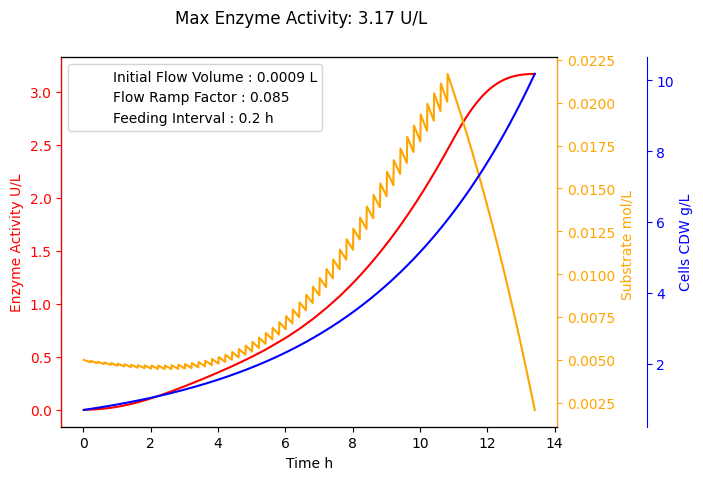

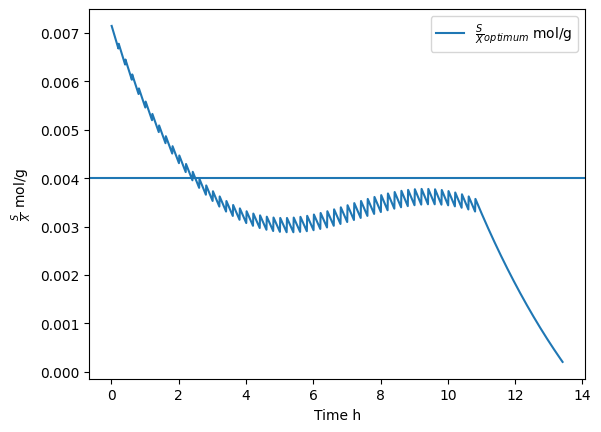

In [5]:
from matplotlib.lines import Line2D

start_flow_volume = best_params['start_flow_volume']
feed_interval = best_params['feed_time']
ramp_factor = best_params['ramp_factor']

#print(f"------------- Experiment {index+1} ------------")
print(f"Start flow volume {start_flow_volume}")
print(f"Feed Interval {feed_interval}")
print(f"Ramp Factor {ramp_factor}")

initial_volume = start_flow_volume
flow_volume = initial_volume
ramp_rate = ramp_factor

# Initial conditions
X0 = config.X0  # CDW g/L 
S0 = config.S0 # mol/L
E0 = config.E0 # U/L 

# Process conditions
T = config.INIT_TEMPRATURE #'C 
T_opt = config.OPTIMUM_TEMPERATURE #'C
A = config.INIT_AGITATION # RPM

# model parameters
Ks = config.KS    # mol/L
Yxs =  config.YXS  # CDW g/mol
MuE_opt = config.MUE_OPT    # U/CDW g
mu_max = config.MU_MAX   # /h
del_t = config.DEL_T # hours ie. 36 seconds
t_end = config.T_END
total_sim_steps = int(t_end/del_t)
tvec = [del_t + i * del_t for i in range(total_sim_steps)]
ns = len(tvec)
kl = config.KL # mol/L
cell_death_timer = config.CELL_DEATH_TIMER
cell_death_time = config.CELL_DEATH_TIME

# Substrate addition calculations
tank_capacity = config.TANK_CAPACITY # L
substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
media_transfer_gap =  feed_interval # Hours this is after 10 steps ie. 6 minutes
media_transfer_step = int(media_transfer_gap/del_t)
substrate_concentration = S0
sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

# external media tank configurations
ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

# X S E delE delX, muE
D = np.zeros((ns+1, 6))
D[0][0] = X0
D[0][1] = substrate_concentration
D[0][2] = E0

for i in range(ns):
    X = D[i][0]
    S = D[i][1]
    E = D[i][2]

    MuX = utils.cell_growth_rate(S)
    # new cells that are generated
    dXdt = utils.cells_produced(X, MuX)

    # SUbstrate consumption
    dSdt = utils.substrate_consumed(dXdt)

    # Find change in cells 
    delX = dXdt * del_t
    # Update cells
    D[i+1][0] = X + delX
    
    # Find change in substrate
    delS = dSdt * del_t

    # # Update substrate
    if substrate_in_tank_liters < max_substrate_limit_liters:
        if i%(media_transfer_step) == 0 and i != 0:
            flow_volume *= math.exp(ramp_rate)
            substrate_action = flow_volume
            if True:
                # get substrate concentraion for current timestep
                substrate_concentration = S
                sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                # Add substrate and calculate new concentraion
                substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                S = substrate_concentration

    # Check if substrate is less than or close to 0
    if S + delS < 0.000001:
        D[i+1][1] = 0
    else:
        D[i+1][1] = S + delS

    # Enzyme determination 
    sub_cell_ratio = (S/X) * 1e6

    weibull = utils.get_weibull_y_value(sub_cell_ratio, peak=config.OPT_SUB_CELL_RATIO*1e6)
    MuE = MuE_opt * weibull

    if dXdt == 0:
        MuE = 0

    # new enzyme from fresh cells
    delE = MuE * X * del_t
    
    # Update enzyme variable
    D[i+1][2] = E + delE

    # terminate if tank capacity is full and cells start dying
    if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
        break


X = D[:,0][0:i]
S = D[:,1][0:i]
E = D[:,2][0:i]
MUE = D[:,5][0:i]
S_C_R = S/X
plt.figure(figsize=(7,5))
max_enzyme = round(max(E),3)
sub_max = round(max(S),3)
max_cells = round(max(X),3)
print(" -----------------------------------------------------------------------")
print(" ----------------------------  Results  --------------------------------")
print(" MAX ENZYME ACTIVITY : ", max(D[:,2]))

fig, ax1 = plt.subplots()
fig.suptitle(f"Max Enzyme Activity: {max_enzyme} U/L" )
#fig.suptitle(f"Simulation: Fed Batch Mode")
ax1.plot(tvec[0:i] ,E ,color="red", label= "Enzyme Activity U/L")

ax2 = ax1.twinx()
ax2.plot(tvec[0:i], S, color="orange", label="Substrate mol/L")

ax3 = ax1.twinx()
ax3.plot(tvec[0:i] , X ,color="blue", label="Cells CDW g/L")
#ax3.spines['right'].set_position(('outward',60))
ax3.spines['right'].set_position(('axes',1.18))

ax1.set_ylabel("Enzyme Activity U/L", color="red")
ax1.set_xlabel("Time h")
ax2.set_ylabel("Substrate mol/L ", color="orange")
ax3.set_ylabel("Cells CDW g/L", color="blue")

ax1.tick_params(axis='y',colors="red")
ax2.tick_params(axis='y',colors="orange")
ax3.tick_params(axis='y',colors="blue")

ax2.spines['right'].set_color("orange")
ax3.spines['right'].set_color("blue")
ax3.spines['left'].set_color("red")
custom_lines = [
    Line2D([0], [0], color='none', marker=None, linestyle='None', label=f'Initial Flow Volume : {start_flow_volume} L'),
    Line2D([0], [0], color='none', marker=None, linestyle='None', label=f'Flow Ramp Factor : {ramp_factor}'),
    Line2D([0], [0], color='none', marker=None, linestyle='None', label=f'Feeding Interval : {feed_interval} h'),

]

# Add the custom legend
plt.legend(handles=custom_lines)
plt.show()

plt.plot(tvec[:len(S_C_R)], S_C_R, label=r"$\frac{S}{X}_{optimum}$ mol/g")
plt.axhline(y=config.OPT_SUB_CELL_RATIO)
plt.xlabel("Time h")
plt.ylabel(r"$\frac{S}{X}$ mol/g")
plt.legend()